# Worksheet 2: Root finding
## - 23MS121 
## - Manish Behera

## Q1.

Use bisection, Secant and Newton-Raphson to solve the equation 3x = tan(x). Plot the
function in the range (0.0, 1.57).

(a) Define a function to call the method, such as, bisection(f,L,R,eps,maxiter), where f is the
function whose root is within bracketing interval L and R.

(b) For bisection, the function should check if the bracketing interval is propper.

(c) The function should check if the given input points are roots.

(d) The function should return the required number of iterations and the root.

(e) For bisection, starting interval could be [1.2,1.4].

(f) For Secant the first two points could be [1.2,1.25].

(g) For Newton-Raphson, the starting point is 1.2.

To solve $tan(x) = 3x$
$$tan(x)- 3x = 0 $$

ie. we find roots for the function $f(x) = tan(x) - 3x$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def f(x):
    return np.tan(x) - 3*x

def f1(x):
    return (1 / np.cos(x))*(1 / np.cos(x)) - 3


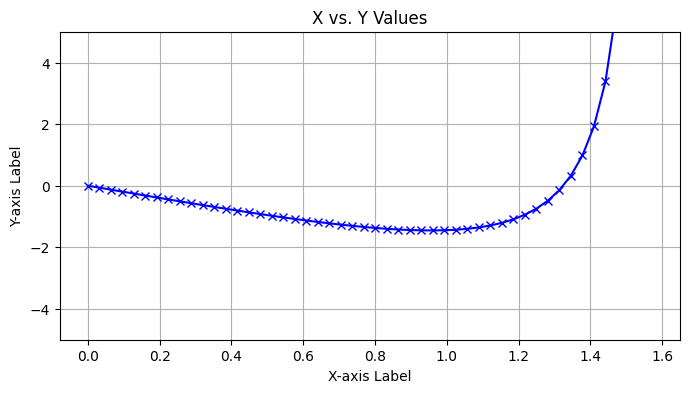

In [3]:
#plotting the function to vizulize 

x_values = np.linspace(0.0, 1.57, 50)
y_values = f(x_values)

# print(x_vals)
# print(y_vals)

plt.figure(figsize=(8, 4)) 
plt.plot(x_values, y_values, marker='x', linestyle='-', color='b') 
plt.ylim(-5,5)
plt.title('X vs. Y Values')
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.grid(True)
plt.show()

In [4]:
def bisection(f,L,R,eps=1.0e-5,maxiter=50):
    """Finds the root of a given function using bisection method within the interval [L, R].

    Args:
        f (function): The function for which to find the root. 
        L (float): The left end of the initial interval [L, R].
        R (float): The right end of the initial interval [L, R].
        eps (float): The tolerance level for convergence, defaults to 1.0e-5.
        maxiter (int): The maximum number of iterations, defaults to 50.

    Returns:
        tuple or None: A tuple containing the number of iterations and the
                       approximate root [iterations, root], or None if the
                       initial range is invalid or the maximum iterations are
                       reached without convergence.
    """
    if f(L)*f(R) > 0:
        print("invalid Range")
        return None
    elif f(L)== 0 or f(R) == 0:
        print("input point is a root")
        return f(L) if f(L) == 0 else f(R)
    else: 
        i = 0
        C = (L+R)/2
        while abs(f(C)) > eps and i < maxiter:
            if f(L) * f(C) < 0:
                R = C
            else:
                L = C
            C = (L + R) / 2
            i += 1
    if i == maxiter and f(C) > eps:
        return None
    return [i, C]

In [5]:
bisection(f, 1.2, 1.4)

[12, 1.3241943359375]

In [6]:
def secant(f, x1, x2, eps=1.0e-5,maxiter=50):
    """Finds the root of a given function using secant method within the interval [x1, x2].

    Args:
        f (function): The function for which to find the root. 
        x1 (float): The left end of the initial interval.
        x2 (float): The right end of the initial interval.
        eps (float): The tolerance level for convergence, defaults to 1.0e-5.
        maxiter (int): The maximum number of iterations, defaults to 50.

    Returns:
        tuple or None: A tuple containing the number of iterations and the
                       approximate root [iterations, root], or None if the maximum iterations are
                       reached without convergence.
    """
    if f(x1)== 0 or f(x2) == 0:
        print("input point is a root")
        return [0, f(x1) if f(x1) == 0 else f(x2)]
    else: 
        i = 0
        x3 = x2-(f(x2)*((x2-x1)/(f(x2)-f(x1))))
        while abs(f(x3)) > eps and i < maxiter:
            x3 = x2-(f(x2)*((x2-x1)/(f(x2)-f(x1))))
            x2,x1 = x3,x2
            i+=1
    if i == maxiter and f(x3) > eps:
        return None
    return [i, x3]

In [7]:
secant(f,1.2,1.25)

[6, np.float64(1.3241944213969474)]

In [8]:
def newton_raphson(f,f1,x1,eps=1.0e-5,maxiter=50):
    """Finds the root of a given function using newton raphson method with the inital guess of x1.

    Args:
        f (function): The function for which to find the root. 
        f1 (function): Derivative of the function f. 
        x1 (float): Initail guess.
        eps (float): The tolerance level for convergence, defaults to 1.0e-5.
        maxiter (int): The maximum number of iterations, defaults to 50.

    Returns:
        tuple or None: A tuple containing the number of iterations and the
                       approximate root [iterations, root], or None if the maximum iterations are
                       reached without convergence.
    """
    if f(x1)== 0:
        print("input point is a root")
        return [0,x1]
    else: 
        i = 0
        x2 = x1 - f(x1)/f1(x1)
        while abs(f(x2)) > eps and i < maxiter:
            x2 = x1 - f(x1)/f1(x1)
            x1 = x2
            i+=1
    if i == maxiter and f(x2) > eps:
        return None
    return [i, x2]

In [9]:
newton_raphson(f,f1,1.2)

[5, np.float64(1.3241948934722485)]

# Q2. 

Consider a particle moving in an asymmetric one-dimensional double-well potential 
$V(x) = x^4 + (2x/3)^3 - x^2$ eV
with a total energy $−0.125 eV$. You need to find the turning points for the particle

when it is in either potential well. Plot the function in the range (−1.25, 1.25).

(a) (4 points) Use Bisection method.

(b) (4 points) Use Secant method.

In [10]:
def v(x):
    return x**4 + (2*x/3)**3 - x**2

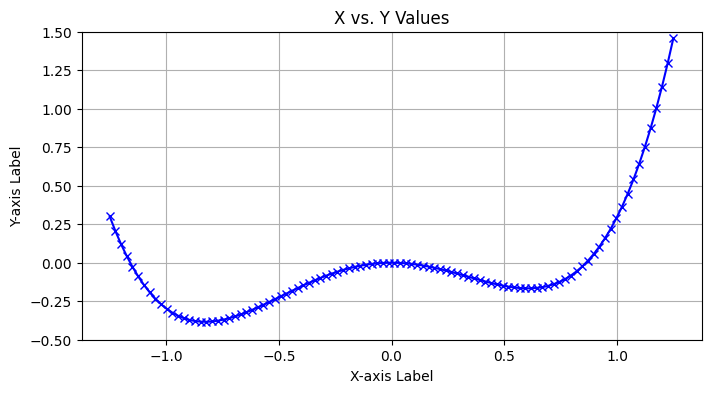

In [11]:
#plotting the function to vizulize 

x_values = np.linspace(-1.25, 1.25, 100)
y_values = v(x_values)

# print(x_vals)
# print(y_vals)

plt.figure(figsize=(8, 4)) 
plt.plot(x_values, y_values, marker='x', linestyle='-', color='b') 
plt.ylim(-0.5,1.5)
plt.title('X vs. Y Values')
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.grid(True)
plt.show()

In [12]:
# at turning point KE = 0 so we need to solve for E = V(x)
# ie f(x) = E - V(x)

def f(x):
    return -0.125 - v(x) 

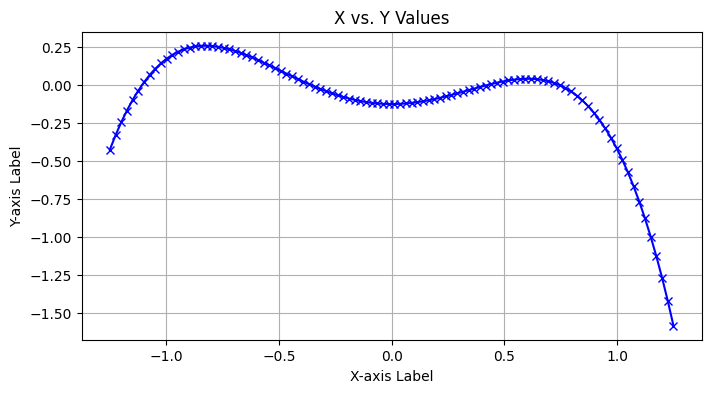

In [13]:
#plotting the function to vizulize 

x_values = np.linspace(-1.25, 1.25, 100)
y_values = f(x_values)

# print(x_vals)
# print(y_vals)

plt.figure(figsize=(8, 4)) 
plt.plot(x_values, y_values, marker='x', linestyle='-', color='b') 
plt.title('X vs. Y Values')
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.grid(True)
plt.show()

In [14]:
# we observe the function has 4 zeroes, we need to divide the domain in chunks and find our roots

ranges = [[-1.25, -0.5],[-0.5,0.0], [0.0, 0.5],[0.5,1.25]]

# Bisection Mtdh
i = 0
for r in ranges:
    L,R = r[0],r[1]
    k, root = bisection(f, L, R)
    print(f"The {i}th root is {root} found in {k} iterations")
    i+=1

The 0th root is -1.1073150634765625 found in 13 iterations
The 1th root is -0.35748291015625 found in 12 iterations
The 2th root is 0.42431640625 found in 9 iterations
The 3th root is 0.744171142578125 found in 12 iterations


In [15]:
#Secant method

ranges = [[-1.25, -0.75],[-0.5,0.0], [0.0, 0.5],[0.75,1.25]]
#neded to change the ranges cuz the Secant method was getting stuck at the maximas

i = 0
for r in ranges:
    L,R = r[0],r[1]
    k, root = secant(f, L, R)
    print(f"The {i}th root is {root} found in {k} iterations")
    i+=1

The 0th root is -1.1073128363646607 found in 10 iterations
The 1th root is -0.35748656094061243 found in 5 iterations
The 2th root is 0.42434773566596956 found in 3 iterations
The 3th root is 0.7441698993065784 found in 4 iterations


In [43]:
#Newton Raphson method
ranges = [[-1.25, -0.5],[-0.5,0.0], [0.0, 0.5],[0.5,1.25]]
i = 0
for r in ranges:
    L,R = r[0],r[1]
    k, root = newton_raphson(f,f1,L)
    print(f"The {i}th root is {root} found in {k} iterations")
    i+=1

The 0th root is -1.1073153719946904 found in 6 iterations
The 1th root is -0.35749899292179965 found in 21 iterations
The 2th root is -0.3574698497844182 found in 26 iterations
The 3th root is 0.7441604400960633 found in 20 iterations
